## 1.	Проверьте, являются ли дисперсии внутри групп гомогенными.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
task_1 = pd.read_csv('C:/Users/majkl/WorkSpace/Project_st_5/task_1.csv')
task_1.head()

,id,group,events
0,16046,A,14
1,18712,A,41
2,3268,A,30
3,22633,A,37
4,28071,A,38


In [3]:
task_2 = pd.read_csv('C:/Users/majkl/WorkSpace/Project_st_5/task_2.csv')
task_2.head()

,id,group,segment,events
0,83440,test,high,78.0
1,96723,test,high,71.0
2,68719,test,high,80.0
3,50399,test,high,80.0
4,95613,test,high,78.0


In [4]:
scipy.stats.levene(task_1.query("group == 'A'").events, 
                   task_1.query("group == 'B'").events, 
                   task_1.query("group == 'C'").events)

LeveneResult(statistic=2.2622596339318037, pvalue=0.1041327199523974)

p-value > 0.05, не отклоняем нулевую гипотезу

## 2.	Проведите тест на нормальность распределения.

In [5]:
scipy.stats.shapiro(task_1[task_1['group'] == 'A']['events'].sample(1000, random_state=17))

ShapiroResult(statistic=0.9973138685756308, pvalue=0.0958664550339529)

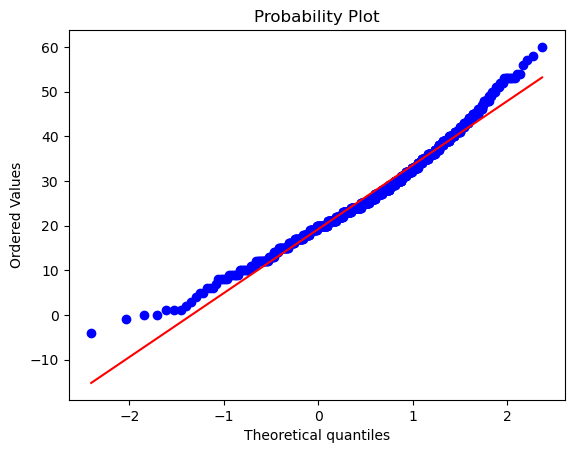

In [6]:
fig = plt.figure()
ax = fig.add_subplot(111)
x = task_1[task_1['group'] == 'A']['events'].sample(1000, random_state=17)
ax.set_title("QQplot группа А")
res = stats.probplot(x, dist=stats.loggamma, sparams=(2.5,), plot=ax)

In [7]:
scipy.stats.shapiro(task_1[task_1['group'] == 'B']['events'].sample(1000, random_state=17))

ShapiroResult(statistic=0.9980819475724109, pvalue=0.3186658905454146)

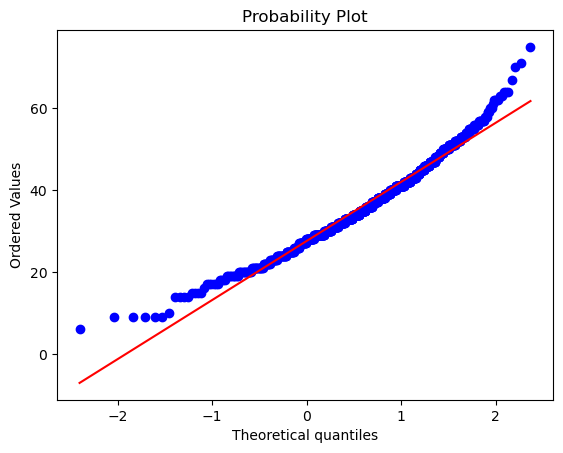

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111)
x = task_1[task_1['group'] == 'B']['events'].sample(1000, random_state=17)
ax.set_title("QQplot группа B")
res = stats.probplot(x, dist=stats.loggamma, sparams=(2.5,), plot=ax)

In [9]:
scipy.stats.shapiro(task_1[task_1['group'] == 'C']['events'].sample(1000, random_state=17))

ShapiroResult(statistic=0.9981201274607922, pvalue=0.3366435414670874)

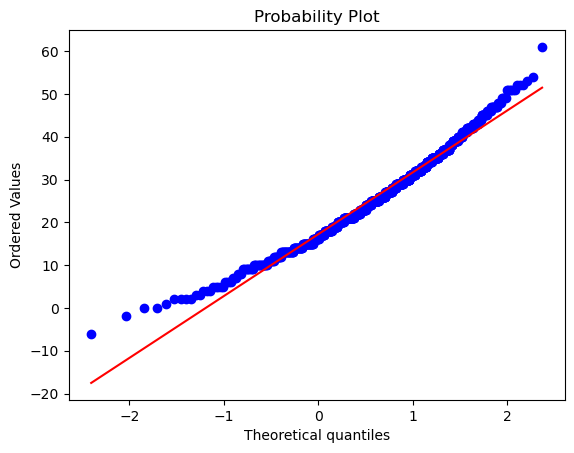

In [10]:
fig = plt.figure()
ax = fig.add_subplot(111)
x = task_1[task_1['group'] == 'C']['events'].sample(1000, random_state=17)
ax.set_title("QQplot группа C")
res = stats.probplot(x, dist=stats.loggamma, sparams=(2.5,), plot=ax)

In [11]:
scipy.stats.shapiro(task_1[task_1['group'] == 'A']['events'])

c:\Users\majkl\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=0.9989209769788764, pvalue=3.3827999572428407e-06)

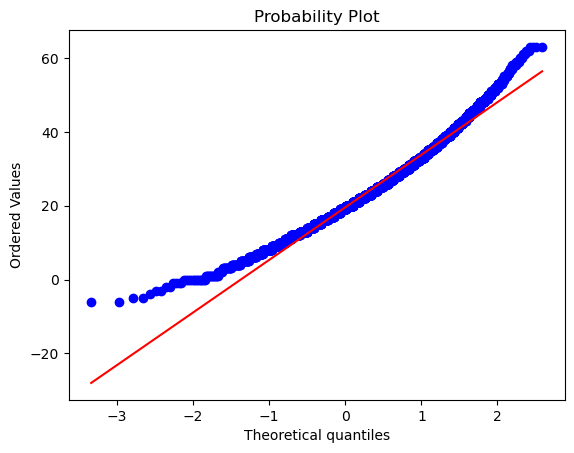

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111)
x = task_1[task_1['group'] == 'A']['events']
ax.set_title("QQplot группа А")
res = stats.probplot(x, dist=stats.loggamma, sparams=(2.5,), plot=ax)

In [13]:
scipy.stats.shapiro(task_1[task_1['group'] == 'B']['events'])

ShapiroResult(statistic=0.9990152741626567, pvalue=1.0400249208438117e-05)

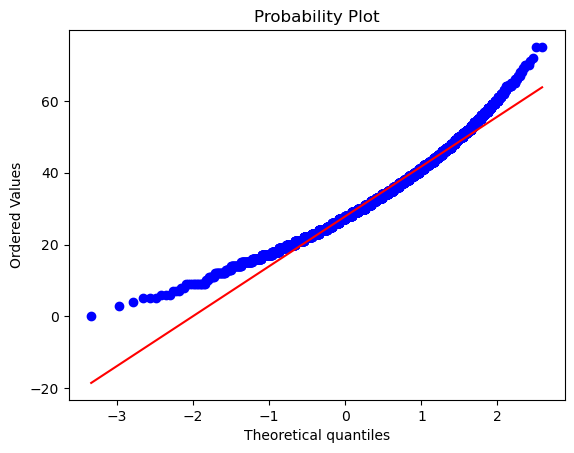

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111)
x = task_1[task_1['group'] == 'B']['events']
ax.set_title("QQplot группа B")
res = stats.probplot(x, dist=stats.loggamma, sparams=(2.5,), plot=ax)

In [15]:
scipy.stats.shapiro(task_1[task_1['group'] == 'C']['events'])

ShapiroResult(statistic=0.9989340547219037, pvalue=3.942400416472453e-06)

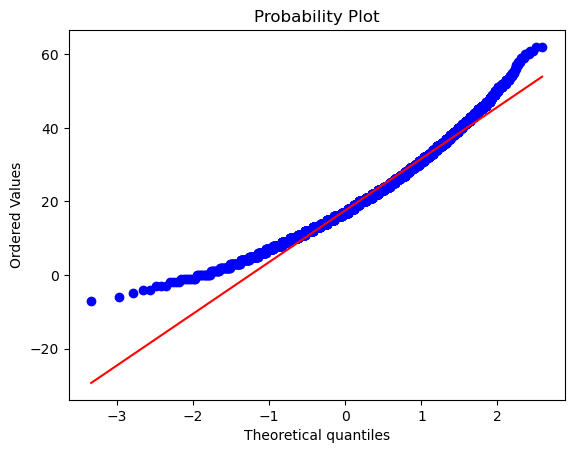

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)
x = task_1[task_1['group'] == 'C']['events']
ax.set_title("QQplot группа C")
res = stats.probplot(x, dist=stats.loggamma, sparams=(2.5,), plot=ax)

Тест Шапиро-Уилка без семплирования дает значения p-value 4.32, 3.39, 1.05

* Распределение events в группах A,B,C является нормальным**


## 3.	Сравните средние в представленных группах.

In [17]:
scipy.stats.f_oneway(task_1.query("group == 'A'").events, 
                     task_1.query("group == 'B'").events, 
                     task_1.query("group == 'C'").events)

F_onewayResult(statistic=2886.166657438961, pvalue=0.0)

Для сравнения средних используtv `ОДНОФАКТОРНЫЙ ДИСПЕРСИОННЫЙ АНАЛИЗ`. Значение статистики равно (окр. до целого) `2886`, а р-уровень значимости составил `0`.

## 4.	Используйте критерий Тьюки и определите, между какими группами есть статистически значимые различия. 

In [18]:
sm.stats.multicomp.pairwise_tukeyhsd(task_1.events, task_1.group).summary()

group1,group2,meandiff,p-adj,lower,upper,reject
A,B,8.034,0.0,7.7038,8.3642,True
A,C,-2.1093,0.0,-2.4395,-1.7791,True
B,C,-10.1433,0.0,-10.4735,-9.8131,True


Статистически значимые различия есть между группами  **A и C**, **B и C**, **A и B**

## 5.	Примите решение: какие картинки в итоге будем использовать?

In [19]:
task_1.groupby('group').agg({'events' : 'sum'})

,events
group,
A,295796
B,376136
C,274703


Квадратные будут оптимальным решением

## 6.	Выберите метод для второго теста.

Во втором эксперименте требуется проверить, как пользователи отреагируют на изменение формата кнопки оформления заказа, с разбивкой по сегменту клиента. Для этого подойдет многофакторный дисперсионный анализ.

## 7.	Визуализируйте распределение events для контрольной и тестовой групп. 

In [20]:
scipy.stats.levene(task_2.query("group == 'test'").events, 
                   task_2.query("group == 'control'").events)

LeveneResult(statistic=2.5440050816535327, pvalue=0.11071679229795423)

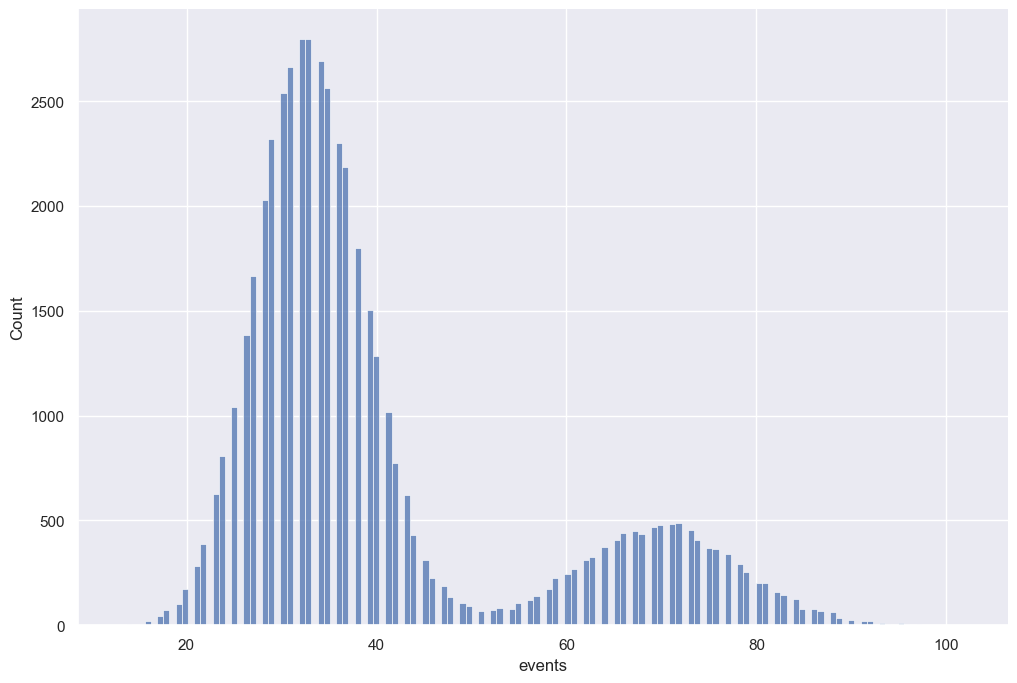

In [23]:
sns.set_style("whitegrid")
sns.set(rc={'figure.figsize':(12,8)})
sns.histplot(task_2.query("group == 'test'").events)
sns.despine()

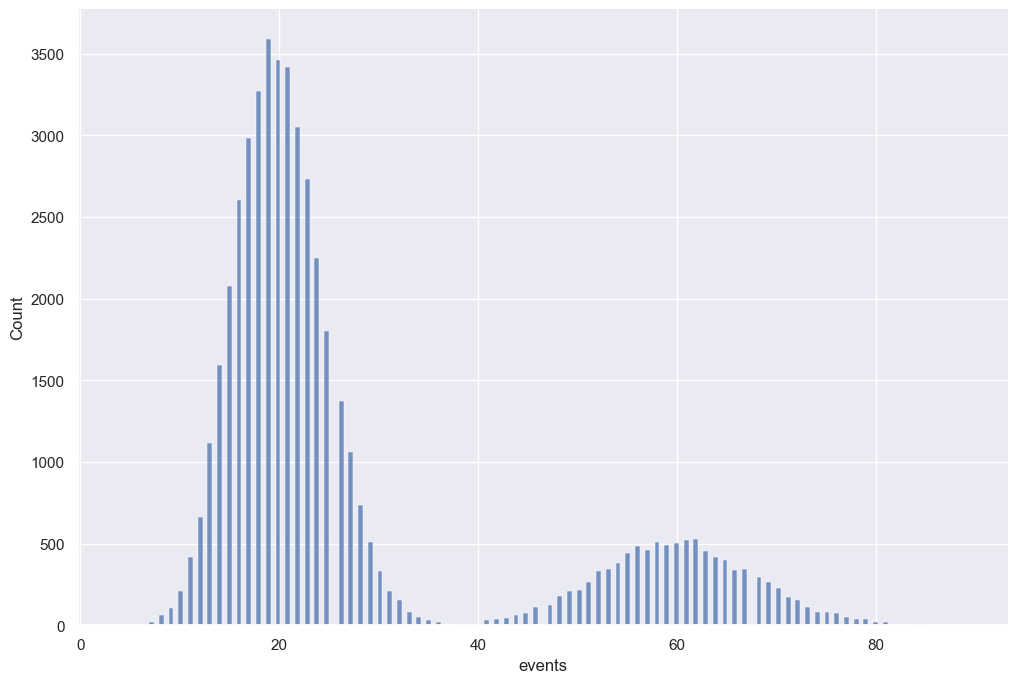

In [24]:
sns.histplot(task_2.query("group == 'control'").events)
sns.despine()

## 8.	Посмотрите на описательные статистики events в разбивке по группе и по сегменту пользователя. 

In [25]:
task_2.groupby(['group', 'segment'], as_index=False).agg({'events' : 'sum'})

,group,segment,events
0,control,high,599708.0
1,control,low,801263.0
2,test,high,699385.0
3,test,low,1321037.0


In [26]:
std_ch = np.round(task_2.query("group == 'control' & segment == 'high'").events.std(), 2)
mean_ch = np.round(task_2.query("group == 'control' & segment == 'high'").events.mean(), 2)
median_ch = np.round(task_2.query("group == 'control' & segment == 'high'").events.median(), 2)
print('Стандартное отклонение контрольной группы в сегменте high = ', std_ch)
print('Среднее контрольной группы в сегменте high = ', mean_ch)
print('Медиана контрольной группы в сегменте high = ', median_ch)

Стандартное отклонение контрольной группы в сегменте high =  7.81
Среднее контрольной группы в сегменте high =  59.97
Медиана контрольной группы в сегменте high =  60.0


In [27]:
std_cl = np.round(task_2.query("group == 'control' & segment == 'low'").events.std(), 2)
mean_cl = np.round(task_2.query("group == 'control' & segment == 'low'").events.mean(), 2)
median_cl = np.round(task_2.query("group == 'control' & segment == 'low'").events.median(), 2)
print('Стандартное отклонение контрольной группы в сегменте low = ', std_cl)
print('Среднее контрольной группы в сегменте low = ', mean_cl)
print('Медиана контрольной группы в сегменте low = ', median_cl)

Стандартное отклонение контрольной группы в сегменте low =  4.47
Среднее контрольной группы в сегменте low =  20.03
Медиана контрольной группы в сегменте low =  20.0


In [28]:
std_th = np.round(task_2.query("group == 'test' & segment == 'high'").events.std(), 2)
mean_th = np.round(task_2.query("group == 'test' & segment == 'high'").events.mean(), 2)
median_th = np.round(task_2.query("group == 'test' & segment == 'high'").events.median(), 2)
print('Стандартное отклонение тестовой группы в сегменте high = ', std_th)
print('Среднее тестовой группы в сегменте high = ', mean_th)
print('Медиана тестовой группы в сегменте high = ', median_th)

Стандартное отклонение тестовой группы в сегменте high =  8.4
Среднее тестовой группы в сегменте high =  69.94
Медиана тестовой группы в сегменте high =  70.0


In [29]:
std_tl = np.round(task_2.query("group == 'test' & segment == 'low'").events.std(), 2)
mean_tl = np.round(task_2.query("group == 'test' & segment == 'low'").events.mean(), 2)
median_tl = np.round(task_2.query("group == 'test' & segment == 'low'").events.median(), 2)
print('Стандартное отклонение тестовой группы в сегменте low = ', std_tl)
print('Среднее тестовой группы в сегменте low = ', mean_tl)
print('Медиана тестовой группы в сегменте low = ', median_tl)

Стандартное отклонение тестовой группы в сегменте low =  5.72
Среднее тестовой группы в сегменте low =  33.03
Медиана тестовой группы в сегменте low =  33.0


## 9.	Выберите формулу для модели, проведите тест.

Формула:
events ~ segment + group + segment:group

In [30]:
task_2['combination'] = task_2['group'] + ' \ ' + task_2['segment']
task_2.head()

<>:1: SyntaxWarning: invalid escape sequence '\ '
<>:1: SyntaxWarning: invalid escape sequence '\ '
C:\Users\majkl\AppData\Local\Temp\ipykernel_1660\2480211273.py:1: SyntaxWarning: invalid escape sequence '\ '
  task_2['combination'] = task_2['group'] + ' \ ' + task_2['segment']


,id,group,segment,events,combination
0,83440,test,high,78.0,test \ high
1,96723,test,high,71.0,test \ high
2,68719,test,high,80.0,test \ high
3,50399,test,high,80.0,test \ high
4,95613,test,high,78.0,test \ high


In [31]:
res = smf.ols(formula = 'events ~ segment + group + segment:group', data=task_2).fit()

In [32]:
sm.stats.anova_lm(res, typ=2)

,sum_sq,df,F,PR(>F)
segment,2.362480e+07,1.0,689756.377485,0.000000e+00
group,3.837195e+06,1.0,112031.864119,0.000000e+00
segment:group,3.664244e+04,1.0,1069.823273,2.060261e-233
Residual,3.424956e+06,99996.0,NaN,NaN


In [33]:
sm.stats.multicomp.pairwise_tukeyhsd(task_2.events, task_2.group).summary()

group1,group2,meandiff,p-adj,lower,upper,reject
control,test,12.389,0.0,12.185,12.593,True


In [34]:
sm.stats.multicomp.pairwise_tukeyhsd(task_2.events, task_2.segment).summary()

group1,group2,meandiff,p-adj,lower,upper,reject
high,low,-38.4259,0.0,-38.5583,-38.2935,True


* Для обоих сегментов показатели статистически значимо _увеличились_ по сравнению с контрольной группой
* Разница между значением у тестовой группы сегмента low и контрольной группой этого же сегмента равна примерно 13
* Разница между control/high и test/high составила около 10


Визуализируем результаты теста

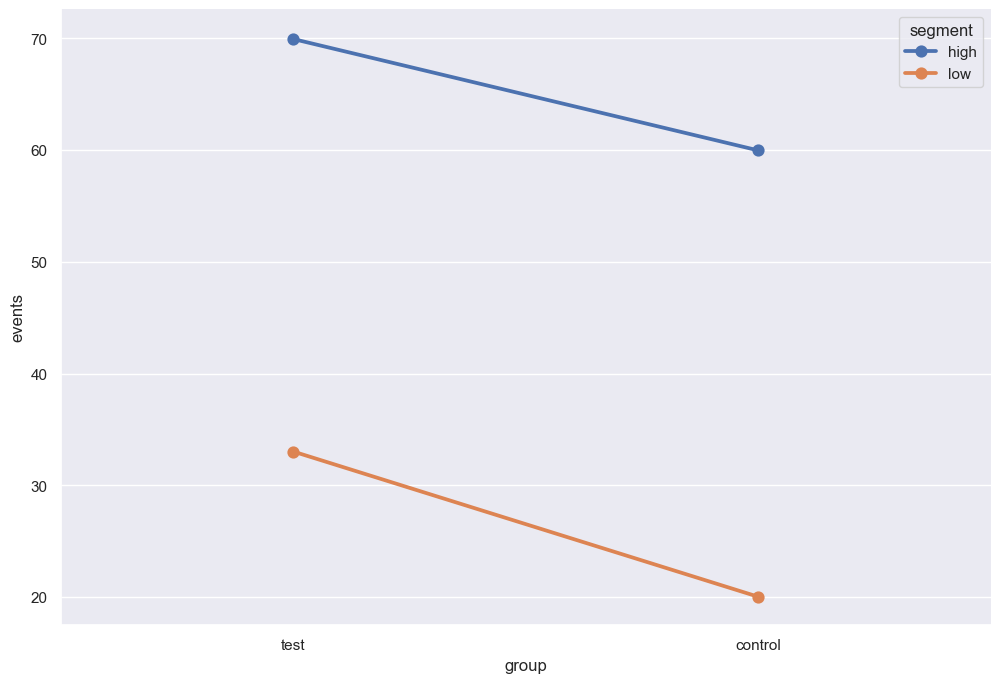

In [35]:
sns.pointplot(x='group' , y='events' , data=task_2, hue='segment')
sns.despine()

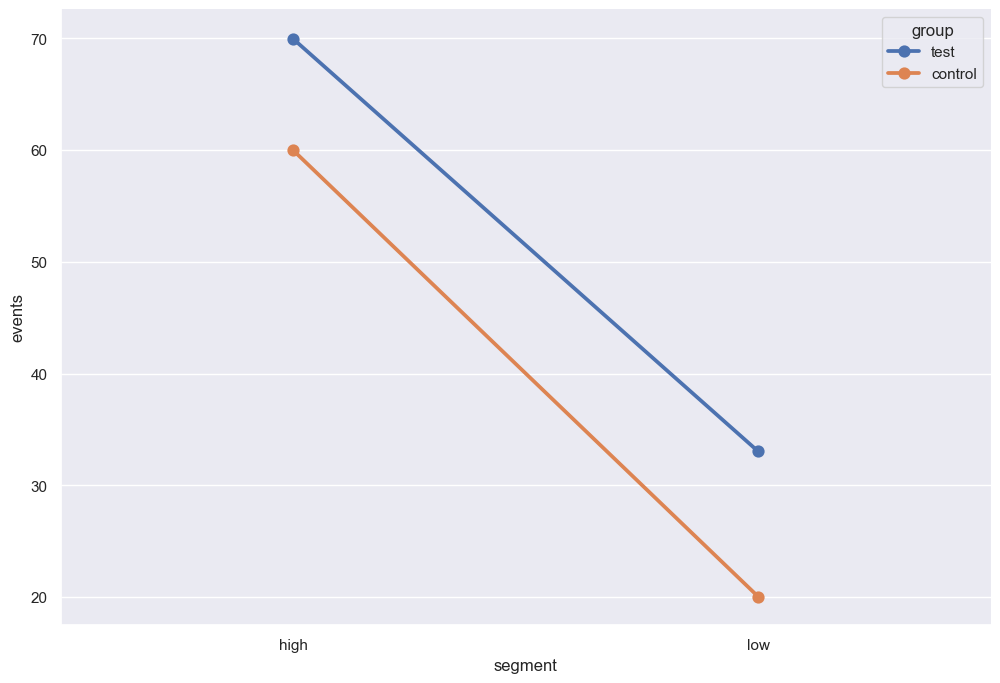

In [36]:
sns.pointplot(x='segment' , y='events' , data=task_2, hue='group')
sns.despine()

Фактор group оказался `ЗНАЧИМЫМ`, фактор segment – `ЗНАЧИМЫМ`, их взаимодействие – `ЗНАЧИМО`. Судя по графику, для всех групп среднее значение events `УВЕЛИЧИЛОСЬ`, поэтому решение: `ВЫКАТЫВАЕМ НОВУЮ ВЕРСИЮ`